Import Pipelines

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

Data Preprocessing

In [ ]:
def load_and_preprocess_data(file_path):
    """Loads the Pima Indians dataset and handles missing values."""
    columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
               'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

    df = pd.read_csv(file_path, names=columns)

    # Convert relevant columns to numeric types, coercing errors to NaN
    numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    #Value of 0 for certain metrics is impossible. Replace 0s with NaNs, then impute them with median of that column.

    cols_to_clean = ['Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI']
    df[cols_to_clean] = df[cols_to_clean].replace(0, np.nan)
    df.fillna(df.median(), inplace=True)

    return df

Clinical Baseline (Proxy Risk Score)

In [ ]:
def calculate_clinical_score(row):
    """
    Calculates a proxy clinical risk score based on traditional ADA guidelines.
    Points are awarded based on Age, BMI, Blood Pressure, and Family History.
    """
    score = 0

    # Age points
    if 40 <= row['Age'] <= 49: score += 1
    elif 50 <= row['Age'] <= 59: score += 2
    elif row['Age'] >= 60: score += 3

    # BMI Points
    if 25 <= row['BMI'] < 30: score += 1
    elif 30 <= row['BMI'] < 40: score += 2
    elif row['BMI'] >= 40: score += 3

    # High BP proxy (if diastolic > 90)
    if row['DiabetesPedigreeFunction'] > 90: score += 1

    # Family History proxy (Pedigree Function > 0.5 signals higher genetic likelihood)
    if row['DiabetesPedigreeFunction'] > 0.5: score += 1

    return score


def apply_clinical_baseline(df):
    """Applies the clinical score and returns a binary prediction (1 = high risk)"""

    # Calculate raw score for each patient
    scores = df.apply(calculate_clinical_score, axis=1)

    # Define threshold for "High Risk"; Threshold is a configurable baseline parameter
    predictions = (scores >= 4).astype(int)

    # Normalize raw scores between 0 and 1 to simulate probabilies for ROC curve
    pseudo_probabilities = scores / scores.max()

    return predictions, pseudo_probabilities

Model Training (Random Forest)

In [ ]:
def train_model(X_train, y_train):
    """Trains a Random Forest Classifier"""
    # I use a Random Forest as it handles non-linear relationships well and provides feature importance

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
    rf_model.fit(X_train, y_train)
    return rf_model

Evaluation & Metrics

In [ ]:
def evaluation_performance(y_true, y_pred, y_prob, method_name="Method"):
    """Calculates and prints Sensitivity, Specificity, Accuracy, and AUC-ROC"""
    accuracy = accuracy_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    # Confusion Matrix to extract True/False Positives/Negatives
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) # True Positive Rate
    specificity = tn / (tn + fp) # True Negative Rate

    print(f"--- {method_name} Performance ---")
    print(f"Accuracy:    {accuracy:.2f}")
    print(f"AUC-ROC:     {roc_auc:.2f}")
    print(f"Sensitivity: {sensitivity:.2f}")
    print(f"Specificity: {specificity:.2f}")

Visualization: Comparison Plot

In [ ]:
def plot_roc_comparison(y_test, rf_probs, baseline_probs):
    """Plots the ROC curves for both the model and clinical baseline."""
    plt.figure(figsize=(8, 6))

    # Calculate ROC curve data
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_probs)

    # Plot Curves
    plt.plot(fpr_rf, tpr_rf, label='Model (Random Forest)', color='blue', linewidth=2)
    plt.plot(fpr_base, tpr_base, label='Clinical Baseline', color='red', linestyle='--', linewidth=2)
    plt.plot([0, 1], [0, 1], color='gray', linestyle=':') # Random guess line

    # Formatting
    plt.title('ROC Curve: Random Forest Model vs. Clinical Baseline')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    plt.show()

Execution

Loading and preprocessing data...
Training model...
--- Clinical Baseline Performance ---
Accuracy:    0.63
AUC-ROC:     0.61
Sensitivity: 0.30
Specificity: 0.81
--- Model (Random Forest) Performance ---
Accuracy:    0.75
AUC-ROC:     0.80
Sensitivity: 0.52
Specificity: 0.88


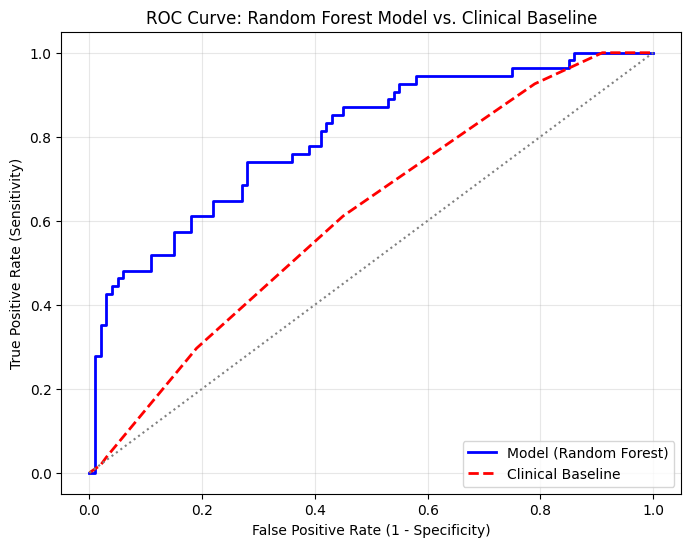

In [ ]:
if __name__ == "__main__":

  # 1. Load and prep
  print("Loading and preprocessing data...")
  # Local CSV file here
  local_file_path = '/content/diabetes.csv'
  df =  load_and_preprocess_data(local_file_path)

  # Features and Target
  X = df.drop('Outcome', axis=1)
  y = df['Outcome']

  # Split data (80% train, 20% test)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

  # Clinical Baseline predictions on TEST set
  baseline_preds, baseline_probs = apply_clinical_baseline(X_test)

  # 3. Train Model and predict on TEST set
  print("Training model...")
  model = train_model(X_train, y_train)
  model_preds = model.predict(X_test)
  model_probs = model.predict_proba(X_test)[:, 1] # Get probabilities for the positive class

  # 4. Generate Performance Report
  evaluation_performance(y_test, baseline_preds, baseline_probs, method_name="Clinical Baseline")
  evaluation_performance(y_test, model_preds, model_probs, method_name="Model (Random Forest)")

  # 5. Visualize
  plot_roc_comparison(y_test, model_probs, baseline_probs)